# PS3

## Problem 1

### (A)

<img src="photos/1a.jpg" width="400" />

### (B)


#### PINN for (A)

In [16]:
# Import TensorFlow and NumPy
import tensorflow as tf
import numpy as np
from pathlib import Path

# Set data type
DTYPE = "float32"
tf.keras.backend.set_floatx(DTYPE)

# Constants: EI = L = w = F = 1 (writeups use P for tip load; code uses F)
L = tf.constant(1.0, dtype=DTYPE)
F = tf.constant(1.0, dtype=DTYPE)  # tip force at x=L, scenario (A)
W = tf.constant(1.0, dtype=DTYPE)  # uniform load intensity w, scenarios (B) and (C)

# PDE: f'''' = Q_load  (set before training: 0 for A, W for B/C with EI=1)
Q_load = tf.Variable(0.0, trainable=False, dtype=DTYPE)


def make_model():
    return tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(1,)),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(1),
        ]
    )


model = make_model()


def f_and_derivs(x):
    """Return f, f', f'', f''', f'''' at x (eager: must stay eager because `model` is replaced each scenario)."""
    x = tf.convert_to_tensor(x)
    with tf.GradientTape(persistent=True) as t4:
        t4.watch(x)
        with tf.GradientTape(persistent=True) as t3:
            t3.watch(x)
            with tf.GradientTape(persistent=True) as t2:
                t2.watch(x)
                with tf.GradientTape() as t1:
                    t1.watch(x)
                    f = model(x)
                f_x = t1.gradient(f, x)
            f_xx = t2.gradient(f_x, x)
        f_xxx = t3.gradient(f_xx, x)
    f_xxxx = t4.gradient(f_xxx, x)
    del t2, t3, t4
    return f, f_x, f_xx, f_xxx, f_xxxx


def residual(x):
    _, _, _, _, f_xxxx = f_and_derivs(x)
    return f_xxxx - Q_load


def mean_square(tensor):
    return tf.reduce_mean(tf.square(tensor))


# Case (A): cantilever, tip load F at x=L (diagram P = F in code), q=0 in domain.
# Part (a) y = F/(6EI)(x^3 - 3Lx^2) gives EI y'''(L) = F at x=L (EI=1).
# If your grader insists on EI v'''(L) = -F from the figure, use shear_free + F instead.
def bc_terms_case_A():
    x_fixed = tf.zeros((1, 1), dtype=DTYPE)
    x_free = tf.ones((1, 1), dtype=DTYPE) * L
    f_fixed, slope_fixed, _, _, _ = f_and_derivs(x_fixed)
    _, _, moment_free, shear_free, _ = f_and_derivs(x_free)
    # Keys must not contain f''' inside "..." — TensorFlow AutoGraph misparses that as an f-string.
    return {
        "disp_0": f_fixed,
        "slope_0": slope_fixed,
        "moment_L": moment_free,
        "shear_L_minus_F": shear_free - F,
    }


# Case (B): cantilever, uniform load — f'''' = w; free end: M=V=0
def bc_terms_case_B():
    x_fixed = tf.zeros((1, 1), dtype=DTYPE)
    x_free = tf.ones((1, 1), dtype=DTYPE) * L
    f_fixed, slope_fixed, _, _, _ = f_and_derivs(x_fixed)
    _, _, moment_free, shear_free, _ = f_and_derivs(x_free)
    return {
        "disp_0": f_fixed,
        "slope_0": slope_fixed,
        "moment_L": moment_free,
        "shear_L": shear_free,
    }


# Case (C): simply supported, uniform load — f=M=0 at both ends
def bc_terms_case_C():
    x0 = tf.zeros((1, 1), dtype=DTYPE)
    xL = tf.ones((1, 1), dtype=DTYPE) * L
    f0, _, m0, _, _ = f_and_derivs(x0)
    fL, _, mL, _, _ = f_and_derivs(xL)
    return {
        "disp_0": f0,
        "disp_L": fL,
        "moment_0": m0,
        "moment_L": mL,
    }


def train_pinn(bc_terms_fn, num_steps=5000, print_every=200, lr=1e-3, N_col=200):
    """Collocation on (0, L); BC residuals from bc_terms_fn."""
    global model
    x_col = np.random.rand(N_col, 1).astype(np.float32) * float(L.numpy())
    x_col = tf.convert_to_tensor(x_col, dtype=DTYPE)
    optimizer = tf.keras.optimizers.Adam(lr)

    @tf.function
    def train_step(xc):
        with tf.GradientTape() as tape:
            r = residual(xc)
            loss_pde = mean_square(r)
            bc = bc_terms_fn()
            loss_bc = tf.constant(0.0, dtype=DTYPE)
            for name in bc:
                loss_bc = loss_bc + mean_square(bc[name])
            loss_total = loss_pde + loss_bc
        grads = tape.gradient(loss_total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss_total, loss_pde, loss_bc

    for step in range(num_steps):
        loss_total, loss_pde, loss_bc = train_step(x_col)
        if step % print_every == 0:
            print(
                "step:", step,
                "  total:", float(loss_total.numpy()),
                "  pde:", float(loss_pde.numpy()),
                "  bc:", float(loss_bc.numpy()),
            )


def local_homework_dir():
    for p in [Path(".").resolve()] + list(Path(".").resolve().parents):
        if (p / "PS3.ipynb").is_file():
            return p
    return Path(".").resolve()


def f_analytic_A(x):
    """Part (a): y = F/(6EI) (x^3 - 3 L x^2); with EI=L=F=1 this is x^3/6 - x^2/2."""
    x = np.asarray(x, dtype=np.float64)
    Lv, Fv = float(L.numpy()), float(F.numpy())
    return (Fv / 6.0) * (x ** 3 - 3.0 * Lv * x ** 2)


def f_analytic_B(x):
    """Part (a): y = (w x^2)/(24 EI) (6 L^2 - 4 L x + x^2); L=w=EI=1 matches homework red box."""
    x = np.asarray(x, dtype=np.float64)
    Lv, wv = float(L.numpy()), float(W.numpy())
    return (wv / 24.0) * x ** 2 * (6.0 * Lv ** 2 - 4.0 * Lv * x + x ** 2)


def f_analytic_C(x):
    """Part (a): y = -w/(24 EI) (x^4 - 2 L x^3 + L^3 x); L=w=EI=1 matches homework red box."""
    x = np.asarray(x, dtype=np.float64)
    Lv, wv = float(L.numpy()), float(W.numpy())
    return -(wv / 24.0) * (x ** 4 - 2.0 * Lv * x ** 3 + (Lv ** 3) * x)


def plot_pinn_vs_analytic(
    title,
    f_analytic_fn,
    save_name,
    *,
    invert_yaxis=True,
    analytic_eq=None,
):
    import matplotlib.pyplot as plt

    Lv = float(L.numpy())
    x_plot = np.linspace(0.0, Lv, 200).reshape(-1, 1).astype(np.float32)
    x_tf = tf.convert_to_tensor(x_plot, dtype=DTYPE)
    f_pinn = model(x_tf).numpy().ravel()
    f_true = f_analytic_fn(x_plot.ravel())

    charts_dir = local_homework_dir() / "charts"
    charts_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_plot.ravel(), f_true, "k-", label="Analytic")
    ax.plot(x_plot.ravel(), f_pinn, "r--", label="PINN")
    if invert_yaxis:
        ax.invert_yaxis()
    ax.set_xlabel("x (along beam)")
    ax.set_ylabel("deflection f(x)")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    if analytic_eq:
        ax.text(
            0.02,
            0.5,
            analytic_eq,
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment="center",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="wheat", alpha=0.9),
        )
    out = charts_dir / save_name
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out.resolve())



In [17]:
# Scenario (A): cantilever, tip load — f'''' = 0 in domain
Q_load.assign(0.0)
model = make_model()
train_pinn(bc_terms_case_A)


step: 0   total: 1.0190595388412476   pde: 0.0009086098289117217   bc: 1.0181509256362915
step: 200   total: 0.0007133532781153917   pde: 0.0005998734850436449   bc: 0.00011347980034770444
step: 400   total: 0.0006066995556466281   pde: 0.00045115090324543417   bc: 0.00015554865240119398
step: 600   total: 4.749956860905513e-05   pde: 3.6620480386773124e-05   bc: 1.0879086403292604e-05
step: 800   total: 2.8000164093100466e-05   pde: 2.691403278731741e-05   bc: 1.086131987904082e-06
step: 1000   total: 2.36538726312574e-05   pde: 2.3634540411876515e-05   bc: 1.9331709566472455e-08
step: 1200   total: 5.9770700318040326e-05   pde: 4.4847867684438825e-05   bc: 1.4922832633601502e-05
step: 1400   total: 2.0341391063993797e-05   pde: 1.9716839233296923e-05   bc: 6.245512622626848e-07
step: 1600   total: 0.0024317384231835604   pde: 0.001965239178389311   bc: 0.0004664993321057409
step: 1800   total: 0.0001836946321418509   pde: 2.1351448594941758e-05   bc: 0.00016234318900387734
step: 2000

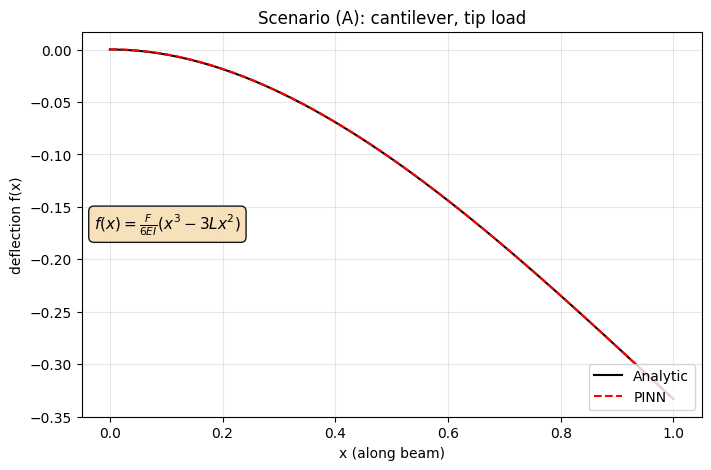

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_A.png
Boundary condition residuals (A):
  disp_0 = [0.00027183]
  slope_0 = [-0.00025749]
  moment_L = [2.4862587e-05]
  shear_L_minus_F = [4.4822693e-05]


In [18]:
# Scenario (A): PINN vs analytic, save under charts/
plot_pinn_vs_analytic(
    "Scenario (A): cantilever, tip load",
    f_analytic_A,
    "1b_A.png",
    invert_yaxis=False,
    analytic_eq=r"$f(x)=\frac{F}{6EI}\left(x^3-3Lx^2\right)$",
)
bc = bc_terms_case_A()
print("Boundary condition residuals (A):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


#### PINN for (B)


In [19]:
# Scenario (B): cantilever, uniform load — f'''' = w (EI=1 → Q_load = W)
Q_load.assign(W)
model = make_model()
train_pinn(bc_terms_case_B)


step: 0   total: 0.5899721384048462   pde: 0.5486840605735779   bc: 0.0412880964577198
step: 200   total: 0.00837371964007616   pde: 0.006702465936541557   bc: 0.0016712535871192813
step: 400   total: 0.0030004503205418587   pde: 0.0029078256338834763   bc: 9.262465755455196e-05
step: 600   total: 0.001602465519681573   pde: 0.0015847162576392293   bc: 1.7749205653672107e-05
step: 800   total: 0.000927821034565568   pde: 0.0009227703558281064   bc: 5.050651452620514e-06
step: 1000   total: 0.0005342842196114361   pde: 0.0005327160470187664   bc: 1.5681896456953837e-06
step: 1200   total: 0.00021669188572559506   pde: 0.00021223870862741023   bc: 4.453173005458666e-06
step: 1400   total: 4.206388985039666e-05   pde: 4.013189027318731e-05   bc: 1.93199775821995e-06
step: 1600   total: 1.961556881724391e-05   pde: 1.925087235576939e-05   bc: 3.646957793534966e-07
step: 1800   total: 1.5256876395142172e-05   pde: 1.5087272004166152e-05   bc: 1.696043767651645e-07
step: 2000   total: 1.4327

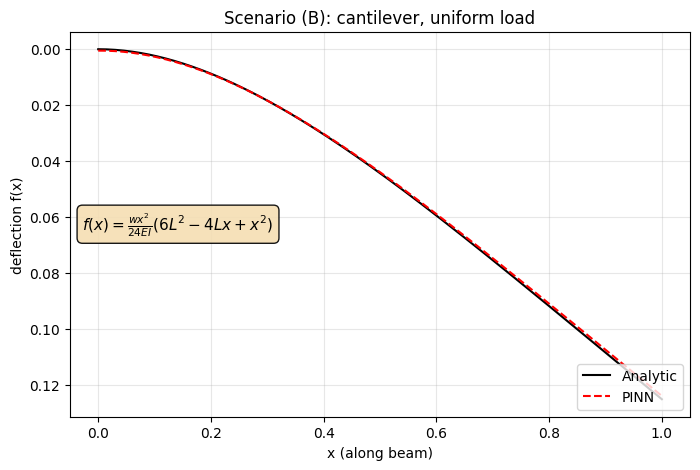

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_B.png
Boundary condition residuals (B):
  disp_0 = [0.00050299]
  slope_0 = [-0.00166413]
  moment_L = [0.00040685]
  shear_L = [0.00011769]


In [20]:
plot_pinn_vs_analytic(
    "Scenario (B): cantilever, uniform load",
    f_analytic_B,
    "1b_B.png",
    analytic_eq=r"$f(x)=\frac{w x^2}{24EI}\left(6L^2-4Lx+x^2\right)$",
)
bc = bc_terms_case_B()
print("Boundary condition residuals (B):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


#### PINN for (C)


In [21]:
# Scenario (C): simply supported, uniform load w (code: W). Part (a) deflection has y'''' = -w/EI with EI=1.
Q_load.assign(-W)
model = make_model()
train_pinn(bc_terms_case_C)


step: 0   total: 0.9609578251838684   pde: 0.9584650993347168   bc: 0.0024927181657403708
step: 200   total: 0.04262430965900421   pde: 0.03710347041487694   bc: 0.0055208406411111355
step: 400   total: 0.0006170193664729595   pde: 0.0006152210989966989   bc: 1.7982747522182763e-06
step: 600   total: 0.0004600304237101227   pde: 0.0004342392785474658   bc: 2.5791152438614517e-05
step: 800   total: 0.0002635960699990392   pde: 0.00026295651332475245   bc: 6.395609943865566e-07
step: 1000   total: 0.00020265066996216774   pde: 0.00020215165568515658   bc: 4.990158117834653e-07
step: 1200   total: 0.00010792318789754063   pde: 9.711916209198534e-05   bc: 1.0804026715049986e-05
step: 1400   total: 7.609151361975819e-05   pde: 7.59352624299936e-05   bc: 1.5625003868535714e-07
step: 1600   total: 2.0395047613419592e-05   pde: 1.793953742890153e-05   bc: 2.4555097297707107e-06
step: 1800   total: 1.5909272406133823e-05   pde: 1.5876545148785226e-05   bc: 3.2727477616845135e-08
step: 2000   to

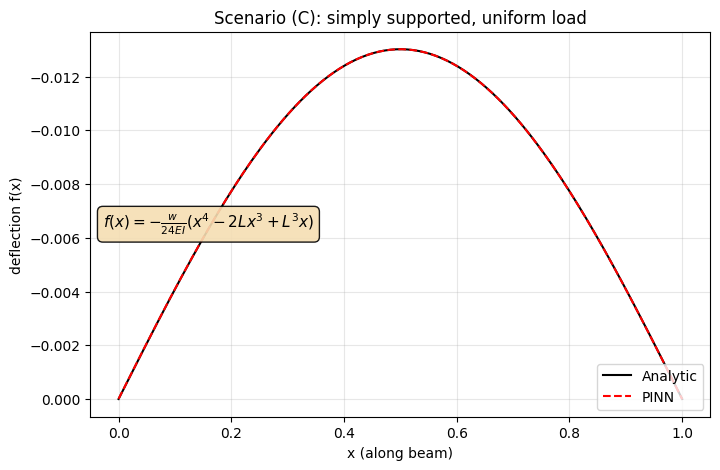

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_C.png
Boundary condition residuals (C):
  disp_0 = [-8.667819e-06]
  disp_L = [7.3239207e-06]
  moment_0 = [-9.285286e-06]
  moment_L = [3.7446618e-05]


In [22]:
plot_pinn_vs_analytic(
    "Scenario (C): simply supported, uniform load",
    f_analytic_C,
    "1b_C.png",
    analytic_eq=r"$f(x)=-\frac{w}{24EI}\left(x^4-2Lx^3+L^3x\right)$",
)
bc = bc_terms_case_C()
print("Boundary condition residuals (C):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


### (C)

(i)

<img src="photos/1c.png" width="600" />

(ii)

<img src="photos/1c_ii.png" width="600" />

## Problem 2


### (A)


In [30]:
# --- Problem 2(a): imports, paths, device ---
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from tqdm.auto import tqdm


def homework_dir() -> Path:
    """Folder that contains PS3.ipynb (works if cwd is elsewhere)."""
    cwd = Path(".").resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / "PS3.ipynb").is_file():
            return p
    return cwd


ROOT = homework_dir()
MANIFEST_CSV = ROOT / "data" / "WebNet_Mar6" / "fullmix.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT.resolve())
print("Manifest:", MANIFEST_CSV.resolve(), "exists:", MANIFEST_CSV.is_file())
print("Device:", device, "| torch:", torch.__version__)


ROOT: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3
Manifest: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\data\WebNet_Mar6\fullmix.csv exists: True
Device: cpu | torch: 2.11.0+cpu


In [31]:
# --- Build PyG Data list from manifest (same logic as WebNet_GNN.ipynb) ---


def graph_folder(rel_dir: str) -> Path:
    """Turn CSV dir entry into absolute path under ROOT/data/..."""
    rel = rel_dir.replace("\\", "/").lstrip("./")
    return (ROOT / "data" / rel).resolve()


def build_data_list(pro_type: str):
    """pro_type: 'Strength' or 'Toughness'."""
    if pro_type not in ("Strength", "Toughness"):
        raise ValueError("pro_type must be 'Strength' or 'Toughness'")

    graph_label_raw = pd.read_csv(MANIFEST_CSV)
    filelist = graph_label_raw["dir"]
    if pro_type == "Strength":
        graph_label_list = graph_label_raw["AverageStrength"]
    else:
        graph_label_list = graph_label_raw["AverageToughness"]

    data_list = []
    for i in range(len(filelist)):
        folder = graph_folder(str(filelist.iloc[i]))
        try:
            node_raw = pd.read_csv(folder / "atomXYZ_final.csv")
            edge_raw = pd.read_csv(folder / "bond_final.csv")

            nx = np.array(node_raw["x"]).reshape(-1, 1)
            ny = np.array(node_raw["y"]).reshape(-1, 1)
            nz = np.array(node_raw["z"]).reshape(-1, 1)
            node_list = np.hstack((nx, ny, nz))

            n1 = np.array(edge_raw["node1"] - 1).reshape(-1, 1)
            n2 = np.array(edge_raw["node2"] - 1).reshape(-1, 1)
            a = np.hstack((n1, n2))
            b = np.hstack((n2, n1))
            ab = np.append(a, b, axis=0)
            edge_list = np.transpose(ab)

            graph_label = np.array(graph_label_list.iloc[i]).reshape(1, -1)

            x = torch.tensor(node_list, dtype=torch.float)
            edge_index = torch.tensor(edge_list, dtype=torch.long)
            y = torch.tensor(graph_label, dtype=torch.float)
            data_list.append(Data(x=x, edge_index=edge_index, y=y))
        except Exception as e:
            print(f"Skip index {i} ({folder}): {e}")

    return data_list


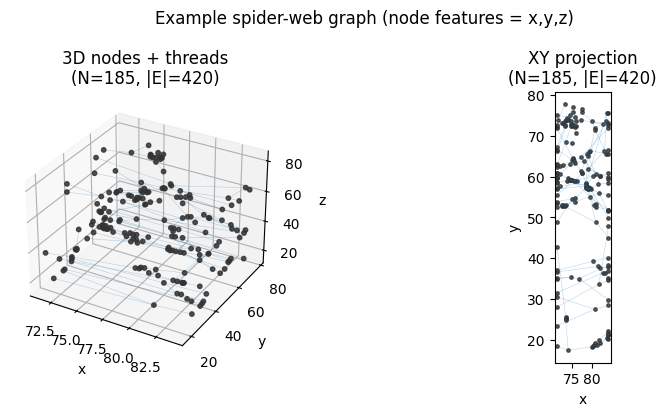

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\sample_web_primary.png


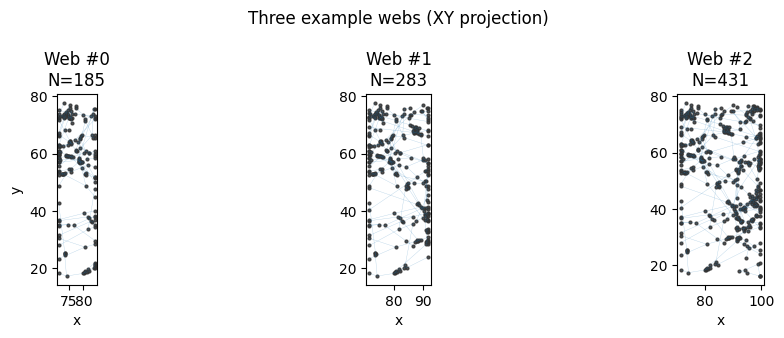

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\sample_web_triptych.png


In [32]:
# --- Visualize a few WebNet graphs (3D + XY projection) ---
# Run after `homework_dir` / `build_data_list` are defined above.

import matplotlib.pyplot as plt

# Load one target only for plotting (geometry is the same for Strength vs Toughness)
_viz_list = build_data_list("Strength")


def plot_single_web(ax3d, ax_xy, data, title_suffix=""):
    """Draw one graph: 3D nodes+edges and an XY top-down view."""
    pts = data.x.detach().cpu().numpy()
    ei = data.edge_index.detach().cpu().numpy()
    # Unique undirected edges for cleaner drawing (bond list is duplicated both ways)
    seen = set()
    edges = []
    for a, b in ei.T:
        u, v = int(a), int(b)
        if u == v:
            continue
        key = (u, v) if u < v else (v, u)
        if key in seen:
            continue
        seen.add(key)
        edges.append((u, v))

    # 3D
    ax3d.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=10, c="0.2", alpha=0.85, depthshade=True)
    for u, v in edges:
        ax3d.plot(
            [pts[u, 0], pts[v, 0]],
            [pts[u, 1], pts[v, 1]],
            [pts[u, 2], pts[v, 2]],
            color="C0",
            lw=0.35,
            alpha=0.35,
        )
    ax3d.set_xlabel("x")
    ax3d.set_ylabel("y")
    ax3d.set_zlabel("z")
    ax3d.set_title("3D nodes + threads" + title_suffix)

    # XY (top-down)
    ax_xy.scatter(pts[:, 0], pts[:, 1], s=6, c="0.2", alpha=0.8)
    for u, v in edges:
        ax_xy.plot(
            [pts[u, 0], pts[v, 0]],
            [pts[u, 1], pts[v, 1]],
            color="C0",
            lw=0.35,
            alpha=0.35,
        )
    ax_xy.set_aspect("equal", adjustable="box")
    ax_xy.set_xlabel("x")
    ax_xy.set_ylabel("y")
    ax_xy.set_title("XY projection" + title_suffix)


# Figure 1 — first graph in detail
if _viz_list:
    d0 = _viz_list[0]
    fig = plt.figure(figsize=(10, 4.2))
    ax3d = fig.add_subplot(1, 2, 1, projection="3d")
    ax_xy = fig.add_subplot(1, 2, 2)
    plot_single_web(
        ax3d,
        ax_xy,
        d0,
        title_suffix=f"\n(N={d0.num_nodes}, |E|={d0.edge_index.shape[1]})",
    )
    fig.suptitle("Example spider-web graph (node features = x,y,z)", fontsize=12)
    plt.tight_layout()
    out1 = ROOT / "charts" / "webnet_gnn" / "sample_web_primary.png"
    out1.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out1, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out1.resolve())

# Figure 2 — three different webs, XY only (quick visual scan)
fig2, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharex=False, sharey=False)
for j, ax in enumerate(axes.ravel()):
    if j >= len(_viz_list):
        ax.axis("off")
        continue
    dj = _viz_list[j]
    pts = dj.x.detach().cpu().numpy()
    ei = dj.edge_index.detach().cpu().numpy()
    seen = set()
    edges = []
    for a, b in ei.T:
        u, v = int(a), int(b)
        if u == v:
            continue
        key = (u, v) if u < v else (v, u)
        if key in seen:
            continue
        seen.add(key)
        edges.append((u, v))
    ax.scatter(pts[:, 0], pts[:, 1], s=4, c="0.2", alpha=0.85)
    for u, v in edges:
        ax.plot(
            [pts[u, 0], pts[v, 0]],
            [pts[u, 1], pts[v, 1]],
            color="C0",
            lw=0.25,
            alpha=0.35,
        )
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"Web #{j}\nN={dj.num_nodes}")
    ax.set_xlabel("x")
    if j == 0:
        ax.set_ylabel("y")
fig2.suptitle("Three example webs (XY projection)", fontsize=12)
plt.tight_layout()
out2 = ROOT / "charts" / "webnet_gnn" / "sample_web_triptych.png"
out2.parent.mkdir(parents=True, exist_ok=True)
fig2.savefig(out2, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out2.resolve())


In [33]:
# --- GCN regression model (graph-level mean pool + linear head) ---


class GCN(torch.nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int = 1):
        super().__init__()
        torch.manual_seed(42)
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = x.to(self.lin.weight.device)
        edge_index = edge_index.to(self.lin.weight.device)
        batch = batch.to(self.lin.weight.device)
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.2, training=self.training)
        return self.lin(x)


In [34]:
# --- Train / validate / test + save curves (per target) ---


def run_training(
    pro_type: str,
    *,
    hidden_channels: int = 32,
    batch_size: int = 32,
    epochs: int = 30,
    lr: float = 0.002,
    random_state: int = 47,
):
    data_list = build_data_list(pro_type)
    if not data_list:
        raise RuntimeError("No graphs loaded; check manifest paths under data/WebNet_Mar6.")

    in_ch = int(data_list[0].num_node_features)

    Train_data, Test_data = train_test_split(data_list, test_size=0.4, random_state=random_state)
    Test_data, Val_data = train_test_split(Test_data, test_size=0.5, random_state=random_state)

    train_loader = DataLoader(Train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Val_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(Test_data, batch_size=batch_size, shuffle=False)

    print(
        f"[{pro_type}] train={len(Train_data)} val={len(Val_data)} test={len(Test_data)} "
        f"| in_features={in_ch}"
    )

    out_root = ROOT / "charts" / "webnet_gnn" / "GCN" / pro_type
    best_dir = out_root / "best_model"
    plot_dir = out_root / "plots"
    for d in (best_dir, plot_dir):
        d.mkdir(parents=True, exist_ok=True)

    model = GCN(in_ch, hidden_channels, 1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=12, min_lr=1e-5)
    mae = torch.nn.L1Loss()

    def train_epoch():
        model.train()
        total, count = 0.0, 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = mae(out.squeeze(), data.y.squeeze())
            loss.backward()
            total += float(loss.item()) * data.num_graphs
            count += data.num_graphs
            optimizer.step()
        return total / max(count, 1)

    @torch.no_grad()
    def eval_mae(loader):
        model.eval()
        total, count = 0.0, 0
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = mae(out.squeeze(), data.y.squeeze())
            total += float(loss.item()) * data.num_graphs
            count += data.num_graphs
        return total / max(count, 1)

    train_maes, val_maes, test_maes = [], [], []
    best_val = float("inf")

    for epoch in tqdm(range(1, epochs + 1), desc=f"GCN / {pro_type}"):
        tr = train_epoch()
        va = eval_mae(val_loader)
        te = eval_mae(test_loader)
        train_maes.append(tr)
        val_maes.append(va)
        test_maes.append(te)
        scheduler.step(va)
        if va < best_val:
            best_val = va
            torch.save(model.state_dict(), best_dir / "model.pt")

    import matplotlib.pyplot as plt

    xs = np.arange(1, epochs + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, train_maes, label="train MAE")
    plt.plot(xs, val_maes, label="val MAE")
    plt.plot(xs, test_maes, label="test MAE")
    plt.xlabel("epoch")
    plt.ylabel("MAE")
    plt.title(f"WebNet GCN — {pro_type}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(plot_dir / "loss_curves.png", dpi=150)
    plt.show()

    print(f"[{pro_type}] best val MAE ≈ {best_val:.4f} | weights → {best_dir / 'model.pt'}")
    print(f"[{pro_type}] plot → {plot_dir / 'loss_curves.png'}")


[Strength] train=120 val=40 test=40 | in_features=3


GCN / Strength: 100%|██████████| 30/30 [00:21<00:00,  1.36it/s]


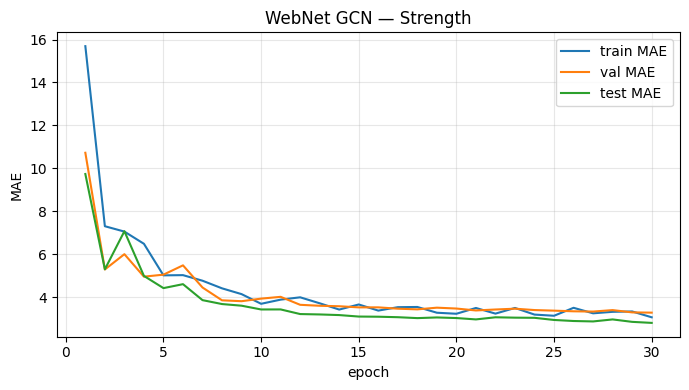

[Strength] best val MAE ≈ 3.2757 | weights → C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\GCN\Strength\best_model\model.pt
[Strength] plot → C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\GCN\Strength\plots\loss_curves.png
[Toughness] train=120 val=40 test=40 | in_features=3


GCN / Toughness: 100%|██████████| 30/30 [00:21<00:00,  1.37it/s]


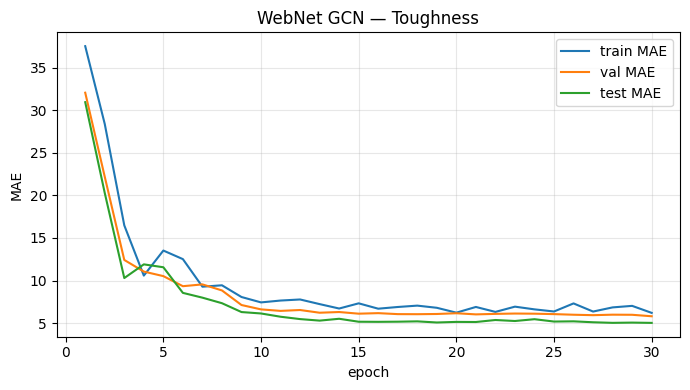

[Toughness] best val MAE ≈ 5.8137 | weights → C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\GCN\Toughness\best_model\model.pt
[Toughness] plot → C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\GCN\Toughness\plots\loss_curves.png


In [35]:
# --- Part (a): train two separate GCN models (strength, then toughness) ---
# Lower `epochs` while debugging; increase for final submission.

run_training("Strength", epochs=30)
run_training("Toughness", epochs=30)


### (B)

I trained two GCNs (one for strength and one for toughness) and plotted MAE vs epoch for train, validation, and test. Both errors drop quickly at first then levels off after about 15 epochs. Train, val, and test stay close with no rising val/test while train keeps improving showing no strong overfitting.

Strength ends near MAE = 3 on all splits. Toughness was slightly different, final MAEs are about 6 (train), 6 (val), and 5 (test) which is larger than strength but the same qualitative pattern.

### (C)

[stats orig]  nodes: mean=993.7 std=295.3   edges (undir): mean=1367.0 std=440.0
[stats +node noise (3 new webs)]  nodes: mean=993.7 std=295.3   edges (undir): mean=1367.0 std=440.0
Strength | node noise: MAE(orig)=3.175  MAE(aug)=3.175  mean|Δpred|=0.000
Toughness | node noise: MAE(orig)=6.452  MAE(aug)=6.452  mean|Δpred|=0.000

=== Part (c): three generated webs - GCN predictions ===
(Geometry is noisy; labels in the last two columns are the *seed* web measurements.)

 web  manifest_idx  pred_strength  pred_toughness  measured_strength_seed  measured_toughness_seed
   1           131      18.584370       38.912670               18.526293                36.329350
   2           181      17.760571       39.449612               14.649590                32.682945
   3            22      17.705307       38.009750               24.060429                48.015343


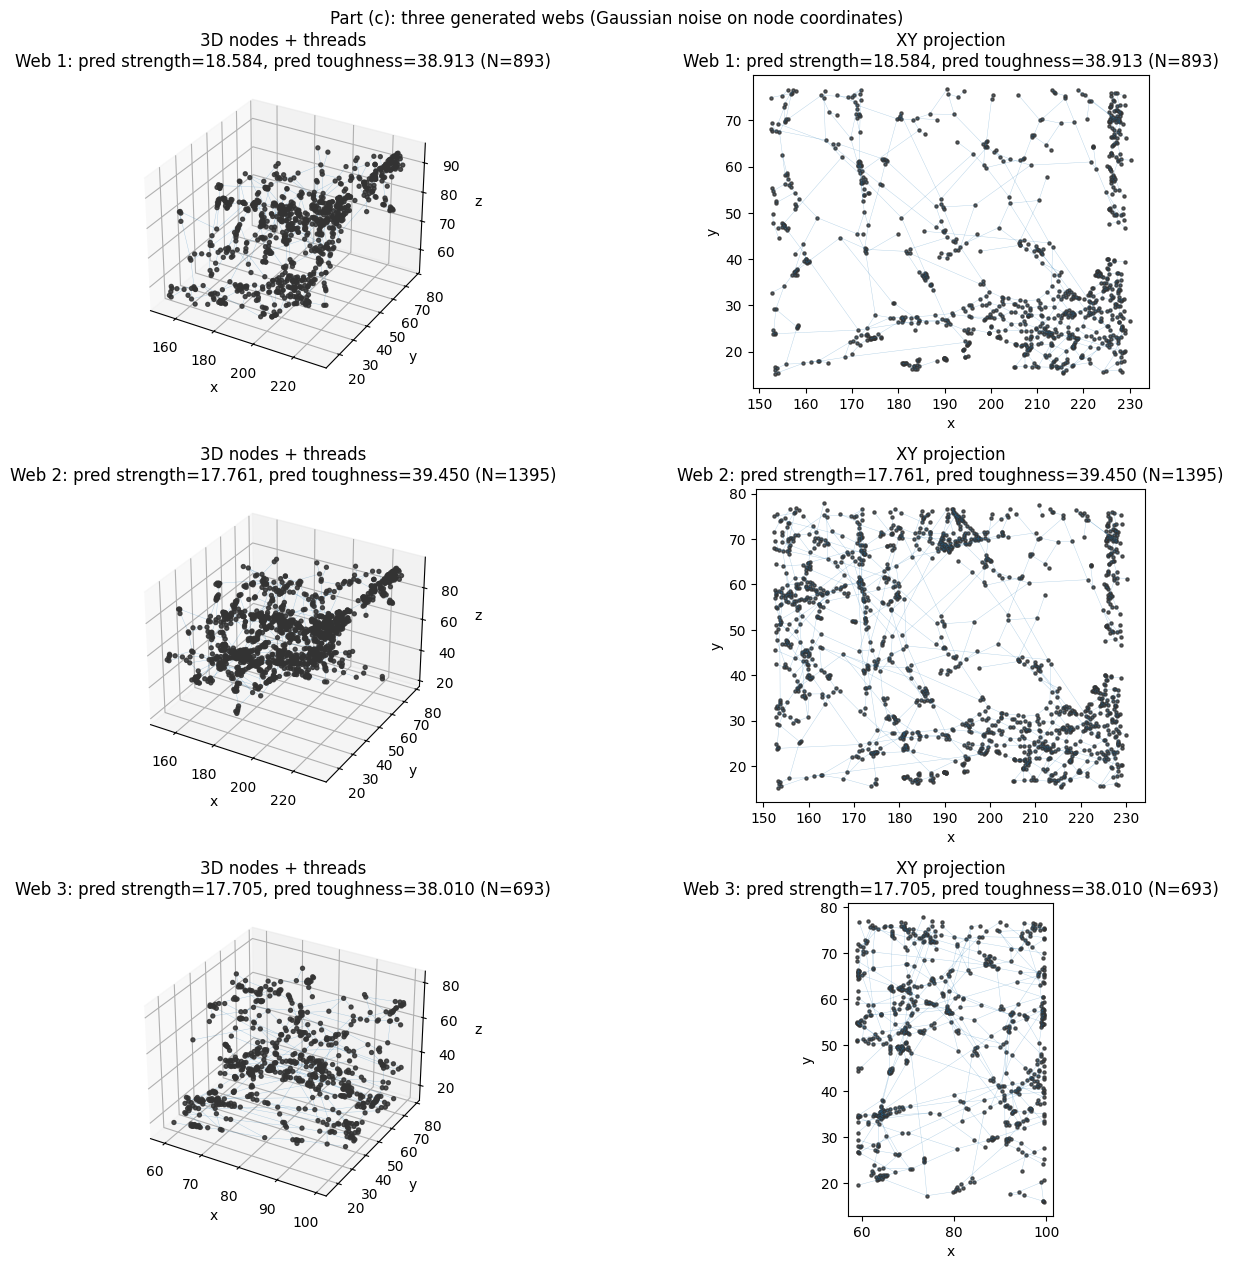

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\webnet_gnn\part_c_three_generated_webs.png


In [37]:
import random


def _data_clone(d: Data) -> Data:
    return Data(x=d.x.clone(), edge_index=d.edge_index.clone(), y=d.y.clone())


def _undirected_unique_pairs(edge_index: torch.Tensor):
    ei = edge_index.cpu().numpy()
    seen = set()
    pairs = []
    for j in range(ei.shape[1]):
        a, b = int(ei[0, j]), int(ei[1, j])
        if a == b:
            continue
        key = (a, b) if a < b else (b, a)
        if key in seen:
            continue
        seen.add(key)
        pairs.append(key)
    return pairs


def augment_node_noise(d: Data, sigma: float) -> Data:
    out = _data_clone(d)
    out.x = out.x + torch.randn_like(out.x) * sigma
    return out


def augment_edge_dropout(d: Data, drop_frac: float, rng: random.Random) -> Data:
    """Drop a fraction of undirected bonds; keep graph connected only in expectation."""
    out = _data_clone(d)
    pairs = _undirected_unique_pairs(out.edge_index)
    if not pairs:
        return out
    kept = [e for e in pairs if rng.random() > drop_frac]
    if not kept:
        return out
    a = np.array([e[0] for e in kept], dtype=np.int64)
    b = np.array([e[1] for e in kept], dtype=np.int64)
    ei = np.stack([np.concatenate([a, b]), np.concatenate([b, a])], axis=0)
    out.edge_index = torch.tensor(ei, dtype=torch.long)
    return out


def graph_stats(d: Data):
    pairs = _undirected_unique_pairs(d.edge_index)
    return {"nodes": int(d.num_nodes), "edges_ud": len(pairs)}


@torch.no_grad()
def predict_list(model: GCN, graphs: list) -> np.ndarray:
    loader = DataLoader(graphs, batch_size=32, shuffle=False)
    parts = []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        parts.append(out.view(-1).cpu().numpy())
    return np.concatenate(parts, axis=0)


def load_trained_gcn(pro_type: str, in_ch: int, hidden_channels: int = 32) -> GCN:
    wpath = ROOT / "charts" / "webnet_gnn" / "GCN" / pro_type / "best_model" / "model.pt"
    if not wpath.is_file():
        raise FileNotFoundError(f"Missing weights (train Part (a) first): {wpath}")
    m = GCN(in_ch, hidden_channels, 1).to(device)
    m.load_state_dict(torch.load(wpath, map_location=device))
    m.eval()
    return m


def summarize(name: str, y_true: np.ndarray, pred_orig: np.ndarray, pred_aug: np.ndarray):
    mae_orig = float(np.mean(np.abs(pred_orig - y_true)))
    mae_aug = float(np.mean(np.abs(pred_aug - y_true)))
    mean_d = float(np.mean(np.abs(pred_aug - pred_orig)))
    print(f"{name}: MAE(orig)={mae_orig:.3f}  MAE(aug)={mae_aug:.3f}  mean|Δpred|={mean_d:.3f}")


# --- run a fixed subsample for speed ---
rng_py = random.Random(0)
torch.manual_seed(0)

strength_graphs = build_data_list("Strength")
toughness_graphs = build_data_list("Toughness")
n = min(len(strength_graphs), len(toughness_graphs))
NUM_SEED_WEBS = 3  # exactly this many new (augmented) webs below
ix = list(range(n))
rng_py.shuffle(ix)
ix = ix[: min(NUM_SEED_WEBS, n)]

orig_s = [strength_graphs[i] for i in ix]
orig_t = [toughness_graphs[i] for i in ix]

SIGMA = 0.05  # noise on coords; reduce if predictions blow up

noise_s = [augment_node_noise(g, SIGMA) for g in orig_s]

# Graph statistics (3 seeds → 3 new webs via node noise only)
for label, seq in [("orig", orig_s), ("+node noise (3 new webs)", noise_s)]:
    nodes = [graph_stats(d)["nodes"] for d in seq]
    edges = [graph_stats(d)["edges_ud"] for d in seq]
    print(f"[stats {label}]  nodes: mean={np.mean(nodes):.1f} std={np.std(nodes):.1f}   "
          f"edges (undir): mean={np.mean(edges):.1f} std={np.std(edges):.1f}")

in_ch = int(orig_s[0].num_node_features)
model_s = load_trained_gcn("Strength", in_ch)
model_t = load_trained_gcn("Toughness", in_ch)

y_s = np.array([float(g.y.ravel()[0]) for g in orig_s], dtype=np.float64)
y_t = np.array([float(g.y.ravel()[0]) for g in orig_t], dtype=np.float64)

# Strength model
p0 = predict_list(model_s, orig_s)
pred_strength_aug = predict_list(model_s, noise_s)
summarize("Strength | node noise", y_s, p0, pred_strength_aug)

# Toughness model (same augmented geometries; labels from toughness manifest)
p0t = predict_list(model_t, orig_t)
pred_toughness_aug = predict_list(model_t, noise_s)
summarize("Toughness | node noise", y_t, p0t, pred_toughness_aug)

# --- Predicted strength & toughness for each *generated* web (trained GCNs) ---
dfc = pd.DataFrame(
    {
        "web": np.arange(1, len(noise_s) + 1, dtype=int),
        "manifest_idx": ix,
        "pred_strength": pred_strength_aug,
        "pred_toughness": pred_toughness_aug,
        "measured_strength_seed": y_s,
        "measured_toughness_seed": y_t,
    }
)
print("\n=== Part (c): three generated webs - GCN predictions ===")
print("(Geometry is noisy; labels in the last two columns are the *seed* web measurements.)\n")
print(dfc.to_string(index=False))

# --- Plot geometry of the three generated webs (3D + XY per row) ---
import matplotlib.pyplot as plt


def _plot_web_panels(ax3d, ax_xy, data, title_3d: str, title_xy: str):
    pts = data.x.detach().cpu().numpy()
    ei = data.edge_index.detach().cpu().numpy()
    seen = set()
    edges = []
    for a, b in ei.T:
        u, v = int(a), int(b)
        if u == v:
            continue
        key = (u, v) if u < v else (v, u)
        if key in seen:
            continue
        seen.add(key)
        edges.append((u, v))

    ax3d.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=8, c="0.2", alpha=0.85, depthshade=True)
    for u, v in edges:
        ax3d.plot(
            [pts[u, 0], pts[v, 0]],
            [pts[u, 1], pts[v, 1]],
            [pts[u, 2], pts[v, 2]],
            color="C0",
            lw=0.3,
            alpha=0.35,
        )
    ax3d.set_xlabel("x")
    ax3d.set_ylabel("y")
    ax3d.set_zlabel("z")
    ax3d.set_title(title_3d)

    ax_xy.scatter(pts[:, 0], pts[:, 1], s=5, c="0.2", alpha=0.8)
    for u, v in edges:
        ax_xy.plot(
            [pts[u, 0], pts[v, 0]],
            [pts[u, 1], pts[v, 1]],
            color="C0",
            lw=0.3,
            alpha=0.35,
        )
    ax_xy.set_aspect("equal", adjustable="box")
    ax_xy.set_xlabel("x")
    ax_xy.set_ylabel("y")
    ax_xy.set_title(title_xy)


fig = plt.figure(figsize=(15, 4.3 * len(noise_s)))
for k, d in enumerate(noise_s):
    tline = (
        f"Web {k + 1}: pred strength={pred_strength_aug[k]:.3f}, "
        f"pred toughness={pred_toughness_aug[k]:.3f} (N={d.num_nodes})"
    )
    ax3d = fig.add_subplot(len(noise_s), 2, 2 * k + 1, projection="3d")
    ax_xy = fig.add_subplot(len(noise_s), 2, 2 * k + 2)
    _plot_web_panels(
        ax3d,
        ax_xy,
        d,
        title_3d="3D nodes + threads\n" + tline,
        title_xy="XY projection\n" + tline,
    )

fig.suptitle("Part (c): three generated webs (Gaussian noise on node coordinates)", fontsize=12)
fig.tight_layout()
_out = ROOT / "charts" / "webnet_gnn" / "part_c_three_generated_webs.png"
_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_out, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", _out.resolve())


### (D)

For manufacturing spider‑web‑like lattice geometries one option is two‑photon lithographysince it can fabricate true 3D microstructures with very high spatial resolution and complex free‑standing architectures. This makes it well‑suited for reproducing thin thread networks and junctions. For larger millimeter‑scale structures lower‑resolution additive methods (e.g SLA) could approximate the geometry, but TPL is the best match when fine features and 3D connectivity matter most (Harinarayana & Shin, *Optics & Laser Technology*, 2021).

## Problem 3

### (A)

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility + device
# -----------------------------
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

# -----------------------------
# UniRef50 data pipeline
# -----------------------------
try:
    from datasets import load_dataset
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "datasets"])
    from datasets import load_dataset

N_TRAIN = 20_000
HF_DATASET = "lamm-mit/UniRef50_512_500K"

print(f"Loading {HF_DATASET} with split train[:{N_TRAIN}] ...")
raw = load_dataset(HF_DATASET, split=f"train[:{N_TRAIN}]")

corpus = [row["Sequence"].strip().upper() for row in raw]
corpus = [s for s in corpus if s]
print(f"Number of training sequences: {len(corpus)}")
print("Example sequences:")
for s in corpus[:3]:
    print(" -", s[:80] + ("..." if len(s) > 80 else ""))

# -----------------------------
# Build vocabulary
# -----------------------------
special_tokens = ["<pad>", "<bos>", "<eos>", "<unk>"]

aas = set()
for line in corpus:
    for ch in line:
        if ch.isalpha():
            aas.add(ch)

vocab = special_tokens + sorted(aas)
stoi = {s: i for i, s in enumerate(vocab)}
itos = {i: s for s, i in stoi.items()}

PAD = stoi["<pad>"]
BOS = stoi["<bos>"]
EOS = stoi["<eos>"]
UNK = stoi["<unk>"]
vocab_size = len(vocab)

print("\nVocab size:", vocab_size)
print("Vocabulary:", vocab)

def tokenize(text, add_bos=True, add_eos=True):
    toks = [c for c in text.strip().upper() if c.isalpha()]
    ids = []
    if add_bos:
        ids.append(BOS)
    ids.extend([stoi.get(tok, UNK) for tok in toks])
    if add_eos:
        ids.append(EOS)
    return ids

def detokenize(token_ids, remove_special=True):
    toks = []
    for idx in token_ids:
        tok = itos.get(int(idx), "<unk>")
        if remove_special and tok in {"<pad>", "<bos>", "<eos>"}:
            continue
        toks.append(tok)
    return "".join(toks)

# -----------------------------
# Sequence prep
# -----------------------------
tokenized_corpus = [tokenize(line) for line in corpus]
max_len = max(len(x) for x in tokenized_corpus)
print("Max sequence length:", max_len)

def sample_batch(batch_size=16):
    batch = random.choices(tokenized_corpus, k=batch_size)
    x_batch, y_batch = [], []
    for ids in batch:
        x = ids[:-1]
        y = ids[1:]
        pad_x = x + [PAD] * ((max_len - 1) - len(x))
        pad_y = y + [PAD] * ((max_len - 1) - len(y))
        x_batch.append(pad_x)
        y_batch.append(pad_y)
    return (
        torch.tensor(x_batch, dtype=torch.long, device=device),
        torch.tensor(y_batch, dtype=torch.long, device=device),
    )



Using device: cpu


c:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading lamm-mit/UniRef50_512_500K with split train[:20000] ...


c:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mpave\.cache\huggingface\hub\datasets--lamm-mit--UniRef50_512_500K. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating trai

Number of training sequences: 20000
Example sequences:
 - MGYIHTALKSAGFHHVIQVDTPALGLDSEGLRKLLADFEPDLVGVSTTTPGLPGAIEACEAAKSTGAKVILGGPHTEVYA...
 - MAKSNQKSDSKAFVLALNHEMIYADKILKFGIFTL
 - MRCAKHSLYGFAVPFFSQKGHRLFYLYIQQ

Vocab size: 26
Vocabulary: ['<pad>', '<bos>', '<eos>', '<unk>', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Max sequence length: 514


In [2]:
# -----------------------------
# Positional encoding
# -----------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, T, C)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# -----------------------------
# Multi-head self-attention
# -----------------------------
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

        self.last_attn = None  # store for visualization

    def forward(self, x, attn_mask=None):
        B, T, C = x.shape

        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)  # (B,H,T,D)
        k = self.k_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (B,H,T,T)

        if attn_mask is not None:
            scores = scores.masked_fill(~attn_mask, float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)
        self.last_attn = attn.detach()

        context = torch.matmul(attn, v)  # (B,H,T,D)
        context = context.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(context)

# -----------------------------
# Feed-forward block
# -----------------------------
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# Transformer block
# -----------------------------
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout=dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout=dropout)

    def forward(self, x, attn_mask=None):
        x = x + self.attn(self.ln1(x), attn_mask=attn_mask)
        x = x + self.ff(self.ln2(x))
        return x

# -----------------------------
# Minimal GPT
# -----------------------------
class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=96, n_heads=4, d_ff=256, n_layers=3, max_len=256, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def make_causal_pad_mask(self, x):
        # x: (B,T)
        B, T = x.shape
        causal = torch.tril(torch.ones(T, T, dtype=torch.bool, device=x.device))  # (T,T)
        causal = causal.unsqueeze(0).unsqueeze(0)  # (1,1,T,T)

        # keys that are real tokens (not PAD)
        key_padding = (x != PAD).unsqueeze(1).unsqueeze(2)  # (B,1,1,T)

        # combine: can only attend to past AND non-pad keys
        mask = causal & key_padding  # (B,1,T,T) by broadcasting
        return mask

    def forward(self, x):
        attn_mask = self.make_causal_pad_mask(x)
        x = self.token_emb(x)
        x = self.pos_enc(x)
        for block in self.blocks:
            x = block(x, attn_mask=attn_mask)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits

model = MiniGPT(
    vocab_size=vocab_size,
    d_model=96,
    n_heads=4,
    d_ff=256,
    n_layers=3,
    max_len=max_len,
    dropout=0.1,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss(ignore_index=PAD)

# -----------------------------
# Training
# -----------------------------
steps = 800
batch_size = 32
loss_history = []

model.train()
for step in range(steps):
    xb, yb = sample_batch(batch_size=batch_size)
    logits = model(xb)  # (B,T,V)
    loss = loss_fn(logits.reshape(-1, vocab_size), yb.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if step % 100 == 0 or step == steps - 1:
        print(f"Step {step:4d} | Loss {loss.item():.4f}")


Step    0 | Loss 3.4070
Step  100 | Loss 2.8605
Step  200 | Loss 2.8460
Step  300 | Loss 2.8331
Step  400 | Loss 2.8045
Step  500 | Loss 2.7812
Step  600 | Loss 2.8500
Step  700 | Loss 2.8104
Step  799 | Loss 2.8193


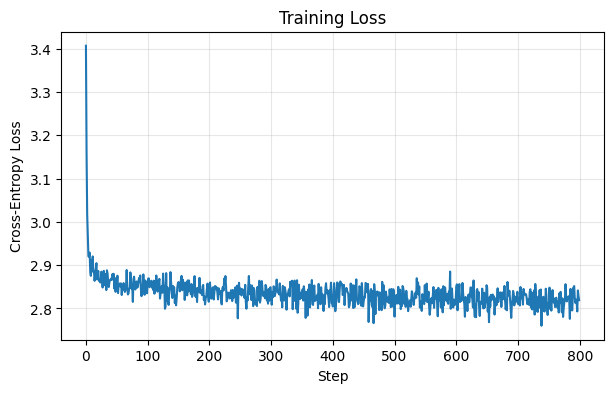

In [3]:
# -----------------------------
# Generation
# -----------------------------
@torch.no_grad()
def generate(prompt, max_new_tokens=12, temperature=1.0, top_k=5):
    model.eval()

    ids = tokenize(prompt, add_bos=True, add_eos=False)
    x = torch.tensor([ids], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        logits = model(x)
        next_logits = logits[:, -1, :] / temperature

        if top_k is not None:
            vals, _ = torch.topk(next_logits, k=min(top_k, next_logits.shape[-1]))
            kth = vals[:, -1].unsqueeze(-1)
            next_logits = torch.where(next_logits < kth, torch.full_like(next_logits, float("-inf")), next_logits)

        probs = F.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        if next_token.item() == EOS:
            break

        x = torch.cat([x, next_token], dim=1)

    return detokenize(x[0].tolist())

# -----------------------------
# Visualization helpers
# -----------------------------
def plot_loss(loss_history):
    plt.figure(figsize=(7, 4))
    plt.plot(loss_history)
    plt.title("Training Loss")
    plt.xlabel("Step")
    plt.ylabel("Cross-Entropy Loss")
    plt.grid(alpha=0.3)
    plt.show()

@torch.no_grad()
def plot_next_token_distribution(prompt, top_n=10, temperature=1.0):
    model.eval()
    ids = tokenize(prompt, add_bos=True, add_eos=False)
    x = torch.tensor([ids], dtype=torch.long, device=device)
    logits = model(x)
    next_logits = logits[0, -1] / temperature
    probs = F.softmax(next_logits, dim=0).detach().cpu().numpy()

    top_idx = np.argsort(probs)[::-1][:top_n]
    top_tokens = [itos[i] for i in top_idx]
    top_probs = probs[top_idx]

    plt.figure(figsize=(8, 4))
    plt.bar(range(len(top_tokens)), top_probs)
    plt.xticks(range(len(top_tokens)), top_tokens, rotation=45)
    plt.title(f"Next-token probabilities after: '{prompt}'")
    plt.ylabel("Probability")
    plt.xlabel("Candidate token")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

@torch.no_grad()
def visualize_attention(prompt, layer_idx=-1, head_idx=0):
    model.eval()
    ids = tokenize(prompt, add_bos=True, add_eos=False)
    x = torch.tensor([ids], dtype=torch.long, device=device)
    _ = model(x)

    attn = model.blocks[layer_idx].attn.last_attn[0, head_idx].cpu().numpy()  # (T,T)
    tokens = [itos[i] for i in x[0].tolist()]

    plt.figure(figsize=(6, 5))
    plt.imshow(attn, aspect="auto", cmap="plasma")
    plt.xticks(range(len(tokens)), tokens, rotation=45)
    plt.yticks(range(len(tokens)), tokens)
    plt.xlabel("Key position")
    plt.ylabel("Query position")
    plt.title(f"Attention map | layer {layer_idx} | head {head_idx}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

def plot_embedding_pca():
    # simple PCA with numpy
    emb = model.token_emb.weight.detach().cpu().numpy()  # (V, D)
    emb_centered = emb - emb.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(emb_centered, full_matrices=False)
    coords = emb_centered @ Vt[:2].T  # (V,2)

    plt.figure(figsize=(7, 6))
    plt.scatter(coords[:, 0], coords[:, 1])
    for i, tok in enumerate(vocab):
        plt.text(coords[i, 0], coords[i, 1], tok, fontsize=9)
    plt.title("Token embedding PCA projection")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(alpha=0.3)
    plt.show()

@torch.no_grad()
def compare_prompts(prompts, max_new_tokens=10):
    print("\nGenerated samples:")
    for p in prompts:
        out = generate(p, max_new_tokens=max_new_tokens, temperature=0.9, top_k=5)
        print(f"Prompt: {p}")
        print(f"Output: {out}")
        print("-" * 60)

# -----------------------------
# Outputs
# -----------------------------
plot_loss(loss_history)



### (B)

### (b) Five de novo protein samples (sampling + temperature sweep)

Generate five sequences from the trained Part (a) MiniGPT using two strategies:
- from-scratch generation
- continuation from partial natural UniRef50 prefixes

Then save all outputs to FASTA for downstream ColabFold / BLAST analysis.

In [4]:
# Part (b): 5-sample generation matrix + FASTA output
# Assumes Part (a) cells already ran in this kernel (model, stoi/itos, BOS/EOS, max_len, corpus, device)

from pathlib import Path

# Reproducible sampling
torch.manual_seed(7)
random.seed(7)
np.random.seed(7)

valid_aas = sorted([tok for tok in stoi.keys() if len(tok) == 1 and tok.isalpha()])
valid_aa_set = set(valid_aas)
print("Valid amino-acid tokens in vocab:", "".join(valid_aas))


def clean_sequence(seq: str) -> str:
    return "".join([ch for ch in seq if ch in valid_aa_set])


@torch.no_grad()
def sample_sequence(prompt: str, max_new_tokens: int, temperature: float = 1.0, top_k: int = 8):
    model.eval()

    # Keep only alphabetic chars from prompt, then tokenize via existing pipeline
    prompt = clean_sequence(prompt.upper())
    ids = tokenize(prompt, add_bos=True, add_eos=False)
    x = torch.tensor([ids], dtype=torch.long, device=device)

    # Safety: model positional encoding supports sequence length up to max_len
    max_steps = min(max_new_tokens, (max_len - 1) - x.shape[1])
    max_steps = max(0, max_steps)

    for _ in range(max_steps):
        logits = model(x)
        next_logits = logits[:, -1, :]

        # Avoid sampling special tokens directly
        next_logits[:, PAD] = -1e9
        next_logits[:, BOS] = -1e9

        # Temperature scaling
        next_logits = next_logits / max(temperature, 1e-6)

        # Top-k filtering
        if top_k is not None and top_k > 0:
            k = min(int(top_k), next_logits.shape[-1])
            vals, _ = torch.topk(next_logits, k=k)
            kth = vals[:, -1].unsqueeze(-1)
            next_logits = torch.where(
                next_logits < kth,
                torch.full_like(next_logits, float("-inf")),
                next_logits,
            )

        probs = torch.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)

        if next_token.item() == EOS:
            break

        x = torch.cat([x, next_token], dim=1)

    seq = detokenize(x[0].tolist(), remove_special=True)
    return clean_sequence(seq)


# Pick 3 natural prefixes (20 aa) from loaded UniRef corpus
natural_prefixes = []
for s in corpus:
    s = clean_sequence(s)
    if len(s) >= 20:
        natural_prefixes.append(s[:20])
    if len(natural_prefixes) == 3:
        break

if len(natural_prefixes) < 3:
    raise RuntimeError("Could not extract three natural 20-aa prefixes from corpus.")


# Agreed 5-sample matrix
experiments = [
    {"id": "S1", "mode": "from_scratch", "prompt": "",                 "temperature": 0.8, "top_k": 5,  "max_new_tokens": 140},
    {"id": "S2", "mode": "from_scratch", "prompt": "",                 "temperature": 1.2, "top_k": 10, "max_new_tokens": 140},
    {"id": "S3", "mode": "natural_prefix", "prompt": natural_prefixes[0], "temperature": 0.8, "top_k": 5,  "max_new_tokens": 120},
    {"id": "S4", "mode": "natural_prefix", "prompt": natural_prefixes[1], "temperature": 1.0, "top_k": 8,  "max_new_tokens": 120},
    {"id": "S5", "mode": "natural_prefix", "prompt": natural_prefixes[2], "temperature": 1.3, "top_k": 12, "max_new_tokens": 120},
]


results = []
for cfg in experiments:
    seq = sample_sequence(
        prompt=cfg["prompt"],
        max_new_tokens=cfg["max_new_tokens"],
        temperature=cfg["temperature"],
        top_k=cfg["top_k"],
    )
    results.append({
        **cfg,
        "sequence": seq,
        "length": len(seq),
    })


# Save FASTA
out_dir = Path("outputs") / "problem3"
out_dir.mkdir(parents=True, exist_ok=True)
fasta_path = out_dir / "part_b_5_samples.fasta"

with open(fasta_path, "w", encoding="utf-8") as f:
    for r in results:
        f.write(f">{r['id']}|mode={r['mode']}|temp={r['temperature']}|topk={r['top_k']}|len={r['length']}\n")
        f.write(r["sequence"] + "\n")


# Print compact summary
print("\nGenerated sequences (Part b):")
for r in results:
    prompt_tag = (r["prompt"][:20] + "...") if len(r["prompt"]) > 20 else r["prompt"]
    print(
        f"{r['id']}: mode={r['mode']:<14} temp={r['temperature']:<3} "
        f"top_k={r['top_k']:<2} len={r['length']:<3} prompt='{prompt_tag}'"
    )
    print("   ", r["sequence"][:120] + ("..." if len(r["sequence"]) > 120 else ""))

print("\nSaved FASTA:", fasta_path.resolve())

Valid amino-acid tokens in vocab: ACDEFGHIKLMNPQRSTUVWXY

Generated sequences (Part b):
S1: mode=from_scratch   temp=0.8 top_k=5  len=140 prompt=''
    MSTLSSSRSTSSLSTSSASSATSATATAASTATSTSSSAATSSSTASSSSSASSSSTTASSSPSRTSSRSSASPPTTTSRSSTRAPSATSSTSAPTPTPSARSSSPTPSSSATSASSSSS...
S2: mode=from_scratch   temp=1.2 top_k=10 len=140 prompt=''
    MRIGSIVAARSPERRTVETSPVTDPPEPPPTPPDEPEPTVADDGVTADRARTSSPATREVVTDDRGAVSTVTVSDGLDVTRTSAEAVLEDEGVDGRSGRSDEVGERGGAASSGVGGPARA...
S3: mode=natural_prefix temp=0.8 top_k=5  len=140 prompt='MGYIHTALKSAGFHHVIQVD'
    MGYIHTALKSAGFHHVIQVDALRLGAGALLAADGGRVVGAGGAVALAAAAVDVGDGGALGAVAAAGGDADALGVLGVLVADGVGDVVGVGAGGVAGVGVVAAAAAAGALDADDVDVAVDV...
S4: mode=natural_prefix temp=1.0 top_k=8  len=140 prompt='MAKSNQKSDSKAFVLALNHE'
    MAKSNQKSDSKAFVLALNHEENENEIIEEDNEEKNNNDNLNSNNSETDTDLENETNSITNITTKKSKTSDSDINKSNSNINLNSKENNDNNSINTKSSTDEINENLIDISSKDTTEKSKE...
S5: mode=natural_prefix temp=1.3 top_k=12 len=140 prompt='MRCAKHSLYGFAVPFFSQKG'
    MRCAKHSLYGFAVPFFSQKGPSVTGIIAVGDIRLPL

I generated five de novo protein candidates using different sampling settings such as from-scratch vs natural-prefix prompting with varied temperature/top-k. The goal was to evaluate how sampling strategy affects sequence diversity and predicted foldability.

Overall, the experiments show a clear trade-off between coherence and creativity:

- Lower-temperature sampling produced more conservative and repetitive sequences.
- Higher-temperature sampling increased novelty.
- Natural-prefix prompting preserved characteristics from the seed sequence, while from-scratch generation explored a wider sequence space.

ColabFold outputs gave the following output for the top-ranked model of each chain:

- `chain1`: mean pLDDT ~ 45.9, pTM ~ 0.17
- `chain2`: mean pLDDT ~ 54.1, pTM ~ 0.16
- `chain3`: mean pLDDT ~ 35.0, pTM ~ 0.18
- `chain4`: mean pLDDT ~ 57.4, pTM ~ 0.13
- `chain5`: mean pLDDT ~ 42.0, pTM ~ 0.21

From these values and the structure images below, predicted confidence is generally **low-to-moderate**, which is expected for short training runs on a small GPT trained from scratch on a subset of UniRef50. Among the five samples, `chain4` and `chain2` appear most promising by average pLDDT, while `chain3` appears least confident.

The model can generate diverse protein-like sequences and sampling controls this diversity meaningfully. However, fold confidence remains limited, indicating that stronger models and longer training would likely be needed for robustly designable proteins.